In [1]:
%load_ext autoreload

import pandas as pd 
%run ../scripts/dataset_builder.py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


On va recommander la catégorie X family 1, mais on veut faire des reco produits, est ce qu'il y en a bcp ?  

In [3]:
products

,ProductID,Category,FamilyLevel1,FamilyLevel2,Universe
0,43220326960179274,Football,Ball,Nike Ordem V,Women
1,622915065731236396,Football,Ball,Nike Ordem V,Men
2,2020543468978812774,Football,Shorts,Nike Dri-FIT,Women
3,600002891277549143,Football,Shorts,Nike Dri-FIT,Women
4,6150916997899913693,Football,Shorts,Nike Dri-FIT,Men
...,...,...,...,...,...
47453,6625957078457954540,Cycling,Bike,Trek Domane SL7,Men
47454,6495275498491778941,Handball,Shoes,Asics Gel-Blast,Women
47455,8112192812403862152,Rugby,Shorts,Adidas Rugby Shorts,Men
47456,1551512279343500105,Softball,Bat,Easton Ghost,Women


In [4]:
stocks

,StoreCountry,ProductID,Quantity
0,AUS,1284651161701379667,2.0
1,AUS,6076274819885027797,2.0
2,AUS,6019386668821120661,2.0
3,AUS,2122575437123245322,2.0
4,AUS,5901681811213086415,2.0
...,...,...,...
16019,ARE,3935326559397911351,9.0
16020,DEU,3935326559397911351,9.0
16021,DEU,6153039859697012898,10.0
16022,ARE,6153039859697012898,10.0


<Axes: ylabel='Frequency'>

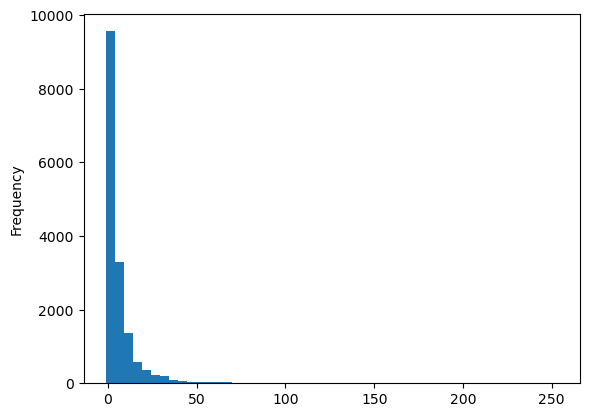

In [12]:
stocks.Quantity.plot(kind="hist", bins=50)

In [5]:
stores

,StoreID,StoreCountry
0,7793989562498223120,BRA
1,5301108587679203543,BRA
2,2908896877692945358,BRA
3,2718131790848668199,BRA
4,7819332417840564556,BRA
...,...,...
601,4492541004792360162,USA
602,8606906800192283162,USA
603,5478106795462651143,USA
604,5524089218753938698,USA


In [14]:
df = (
    stocks
    .merge(stores, on="StoreCountry")
    .merge(products, on="ProductID")
)


In [9]:
df

,StoreCountry,ProductID,Quantity,StoreID,Category,FamilyLevel1,FamilyLevel2,Universe
0,AUS,1284651161701379667,2.0,8093793881868997871,Football,Shorts,Nike Dri-FIT,Women
1,AUS,1284651161701379667,2.0,3087473989102446590,Football,Shorts,Nike Dri-FIT,Women
2,AUS,1284651161701379667,2.0,2940401694407718221,Football,Shorts,Nike Dri-FIT,Women
3,AUS,1284651161701379667,2.0,3044180916065588963,Football,Shorts,Nike Dri-FIT,Women
4,AUS,1284651161701379667,2.0,3841586011955476393,Football,Shorts,Nike Dri-FIT,Women
...,...,...,...,...,...,...,...,...
1687258,FRA,6153039859697012898,10.0,8122717388959329665,Football,Shoes,New Balance Furon,Men
1687259,FRA,6153039859697012898,10.0,6332090558343235680,Football,Shoes,New Balance Furon,Men
1687260,FRA,6153039859697012898,10.0,1816064305697195851,Football,Shoes,New Balance Furon,Men
1687261,FRA,6153039859697012898,10.0,4578927201467322202,Football,Shoes,New Balance Furon,Men


In [24]:
df["catfam"] = df["Category"] + " - " + df["FamilyLevel1"]

In [25]:
df.groupby(["catfam","StoreCountry"])["ProductID"].count()

catfam                  StoreCountry
Badminton - Racket      ARE              4356
                        AUS              7540
                        DEU              4200
                        FRA             25900
                        GBR               150
                                        ...  
Volleyball - Knee Pads  ARE              1221
                        AUS              1768
                        DEU              1170
                        FRA              7215
                        USA              9116
Name: ProductID, Length: 197, dtype: int64

<Axes: ylabel='Frequency'>

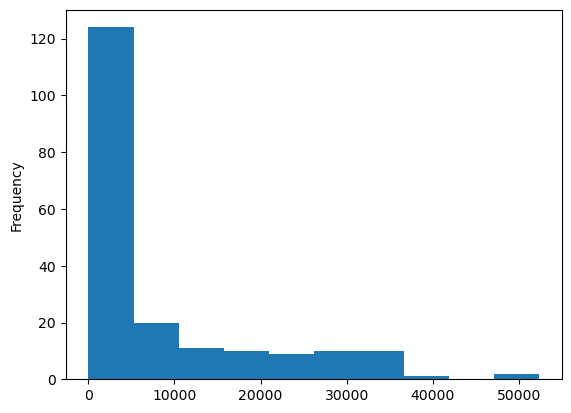

In [27]:
df.groupby(["catfam","StoreCountry"])["ProductID"].count().plot(kind="hist")

In [28]:
df.groupby(["catfam","StoreCountry"])["ProductID"].count().describe()

count      197.000000
mean      8564.786802
std      10968.805947
min         30.000000
25%       1221.000000
50%       3663.000000
75%      12950.000000
max      52355.000000
Name: ProductID, dtype: float64

> environ 8000 références dans le pays par catfam